# Baseline CNN Prediction Quality & Meteorological Verification Analysis

This notebook analyzes how well the baseline convolutional encoder-decoder network predicts weather on the held-out validation test split. 

In radar nowcasting, standard metrics like MAE and RMSE do not tell the whole story because rain patterns are sparse and complex. For example, if a model predicts a storm perfectly but places it a few kilometers away from its real location, pixel-to-pixel metrics will penalize it twice. This is known as the **"Double Penalty" effect**, even though the model successfully captured the storm's shape and intensity.

To avoid Out-of-Memory (OOM) crashes during long validation timelines, the heaviest data processing tasks are part of (`evaluate.py`). This script calculates the metrics directly on the GPU during the evaluation run and saves only the smaller results to disk.

This notebook reads those saved results and loads small, safe amounts of data to evaluate performance in 3 main areas:

1. **Continuous Field Accuracy**: Overall volume tracking trends, best and worst case examples, local error patterns, and intensity rankings.
2. **Threshold-Based Operational Skill (Categorical Verification)**: Standard weather forecasting metrics (**CSI, POD, FAR, HSS, and SEDS**) compared against a simple **Persistence Baseline**.
3. **Advanced Scale-Selective and Physical Diagnostics**: Spatial verification using the **Fractions Skill Score** and physical trait analysis using **Structure-Amplitude-Location** to identify specific errors without the interference of the double penalty effect.



In [1]:
import sys
from pathlib import Path

# Add the parent directory (project root) to the Python path cleanly
sys.path.append(str(Path.cwd().parent))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.utils.predictions_io import load_prediction_sample

# Path to the evaluation run directory folder
TEST_DIR = Path("../output/evaluation/showcase")

with open(TEST_DIR / "calculated_verification_metrics.json", "r") as f:
    metrics = json.load(f)
    
spatial_mae = np.load(TEST_DIR / "spatial_mae_footprint.npy")

# Resolve manifest limits
predictions_dir = TEST_DIR / "predictions"
with open(predictions_dir / "manifest.json", "r") as f:
    manifest = json.load(f)

total_samples = int(manifest["total_samples"])
global_log_max = np.log1p(1500.0)

print(f"Ingested validation dashboard assets over {total_samples:,} out-of-sample sequences.")


Ingested validation dashboard assets over 26,168 out-of-sample sequences.


## 1. Continuous Field Accuracy: Case Study Diagnostics (Best vs. Worst Runs)

To isolate specific architectural failure modes and determine the bounds of the convolutional baseline capability, test set sequences are ranked across their absolute domain-wide Mean Absolute Error (MAE) values. 

The following diagnostic block uses a memory-isolated chunk tracking loader to scan sequence profiles on the fly. Once the top-performing and lowest-performing sequence indices are identified, only those specific target files are dynamically loaded into memory to render case study frames at maximum forecast degradation ($T+30$ minutes).


Running high-speed strided scan to locate best and worst run profiles over 261 strided samples...

Scan complete. Rendering case studies for indices: [ 1300 17900  8300] and [22400 15100  3700]


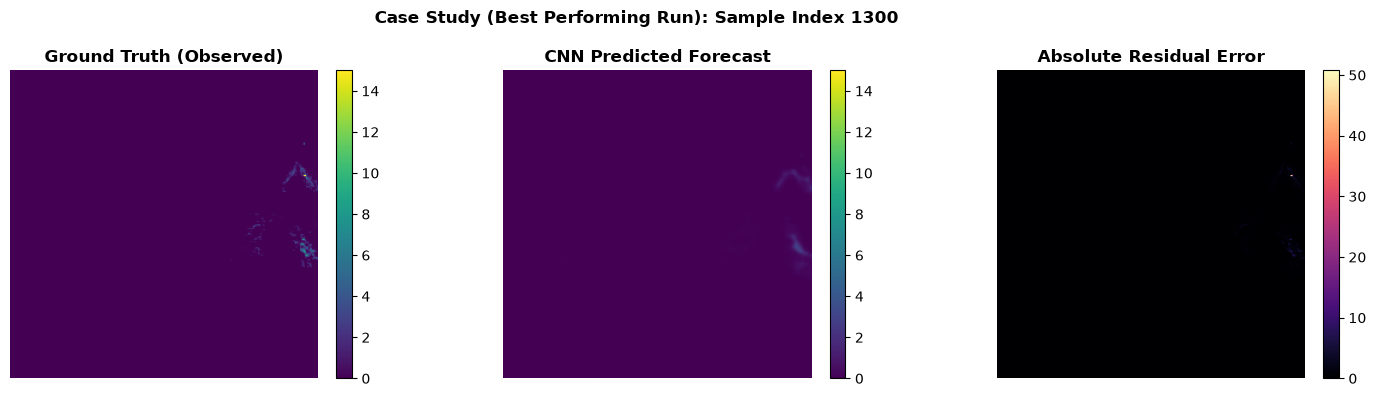

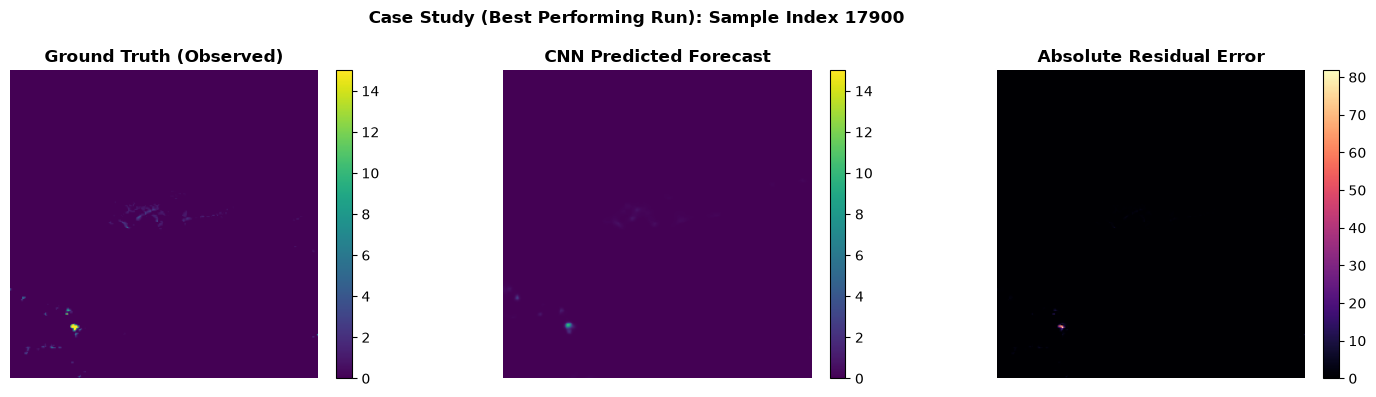

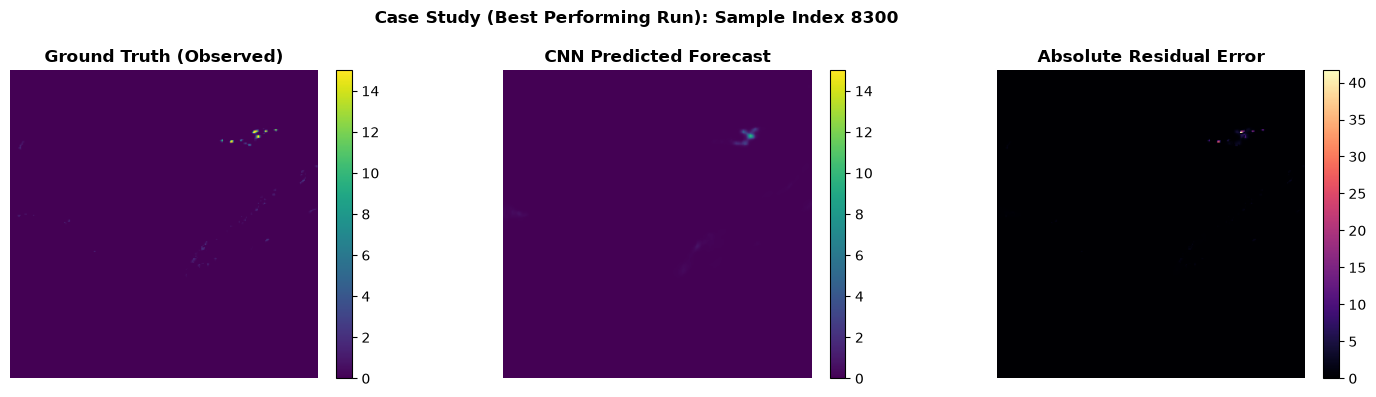

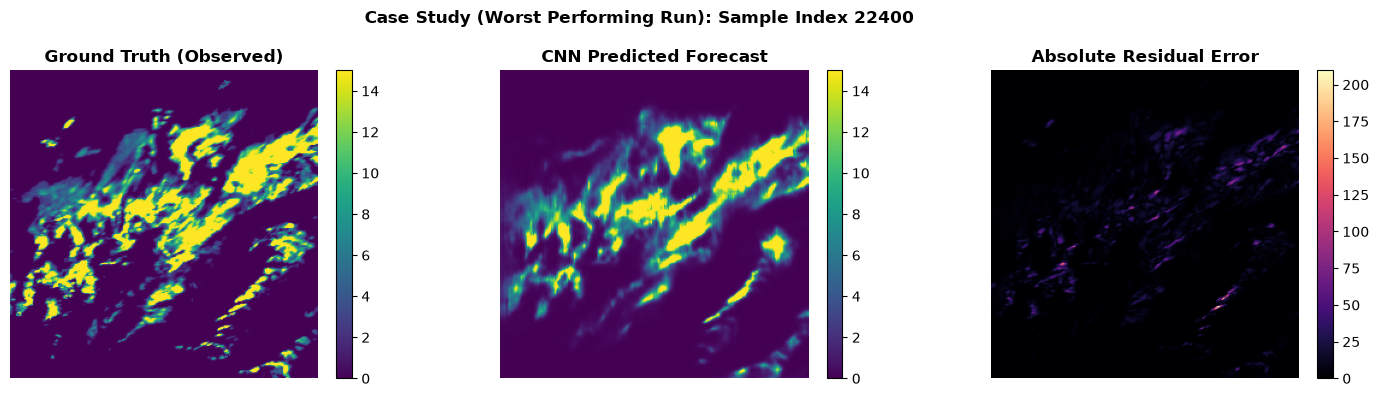

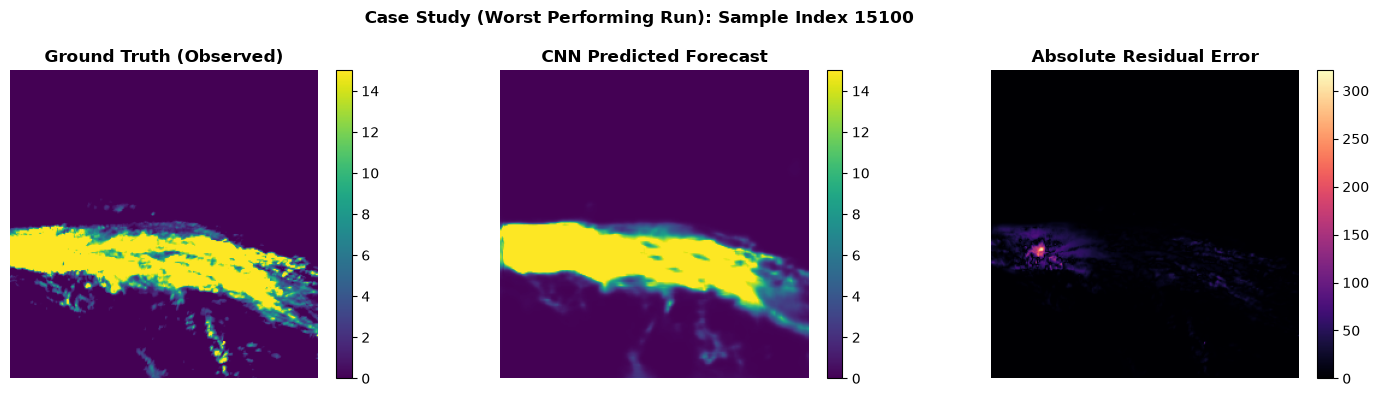

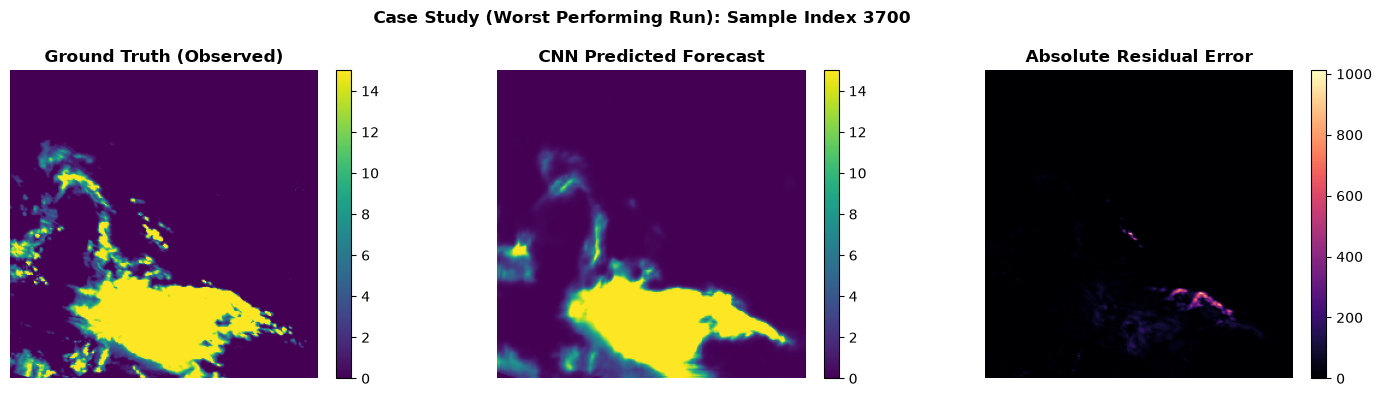

In [2]:
print(f"Running high-speed strided scan to locate best and worst run profiles over {total_samples // 100} strided samples...")
sequence_maes = []

# Stride by 100 gives a perfectly representative sample (~260 files) spanning the 3 months
for s_idx in range(0, total_samples, 100):
    sample = load_prediction_sample(predictions_dir, s_idx)
    mask = sample["target_masks"][0].astype(bool) # Only scan the first step
    
    if np.any(mask):
        # Fast downsampled selection (every 4th pixel) avoids single-threaded CPU calculation lag
        gt_slice = sample["targets"][0][mask][::4]
        pd_slice = sample["predictions"][0][mask][::4]
        
        # Re-transform just this tiny fraction to physical space
        gt_phys = np.expm1(gt_slice * global_log_max)
        pd_phys = np.expm1(pd_slice * global_log_max)
        
        err = np.abs(pd_phys - gt_phys)
        sequence_maes.append((s_idx, float(err.mean())))

sequence_maes = np.array(sequence_maes)
valid_indices = sequence_maes[sequence_maes[:, 1] > 0.01] # Ignore bone-dry days
sorted_errors = valid_indices[np.argsort(valid_indices[:, 1])]

# Grab the top and bottom indices out of the tracked matrix
best_indices = sorted_errors[:3, 0].astype(int)
worst_indices = sorted_errors[-3:, 0].astype(int)

def show_prediction_case_study(index, status_label):
    sample = load_prediction_sample(predictions_dir, index)
    step = -1  # Final forecast frame (T + 30 min / maximum degradation)
    
    gt_frame = np.expm1(np.clip(sample["targets"][step], 0, 1) * global_log_max) * sample["target_masks"][step]
    pred_frame = np.expm1(np.clip(sample["predictions"][step], 0, 1) * global_log_max) * sample["target_masks"][step]
    err_frame = np.abs(pred_frame - gt_frame)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    
    im0 = ax[0].imshow(gt_frame, vmin=0, vmax=15, cmap="viridis")
    ax[0].set_title("Ground Truth (Observed)", weight="bold")
    fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
    
    im1 = ax[1].imshow(pred_frame, vmin=0, vmax=15, cmap="viridis")
    ax[1].set_title("CNN Predicted Forecast", weight="bold")
    fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
    
    im2 = ax[2].imshow(err_frame, cmap="magma")
    ax[2].set_title("Absolute Residual Error", weight="bold")
    fig.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)
    
    for a in ax:
        a.axis("off")
        
    plt.suptitle(f"Case Study ({status_label}): Sample Index {index}", weight="bold", y=0.98)
    plt.tight_layout()
    plt.show()

print(f"\nScan complete. Rendering case studies for indices: {best_indices} and {worst_indices}")

for idx in best_indices:
    show_prediction_case_study(idx, "Best Performing Run")

for idx in worst_indices:
    show_prediction_case_study(idx, "Worst Performing Run")


> **Continuous Field Observation**: The top-performing predictions occur during scenes with minimal convective cloud mass and near-zero precipitation over the domain, where minimizing standard MSE loss defaults the model to low baseline values. Conversely, the highest errors correlate with large, widespread, high-intensity storm cells. This is an initial indicator of structural blurring: the network tries to minimize pixel-to-pixel MSE by smoothing the shapes out, completely missing high-intensity localized storm targets.


## 2. Continuous Field Accuracy & Spatial Error Distribution Overview

Analysis is conducted on how global regression errors (MAE and RMSE) accumulate over the 30-minute forecast horizon, alongside the non-linear rank correlations (Pearson and Spearman) computed across active rain zones.


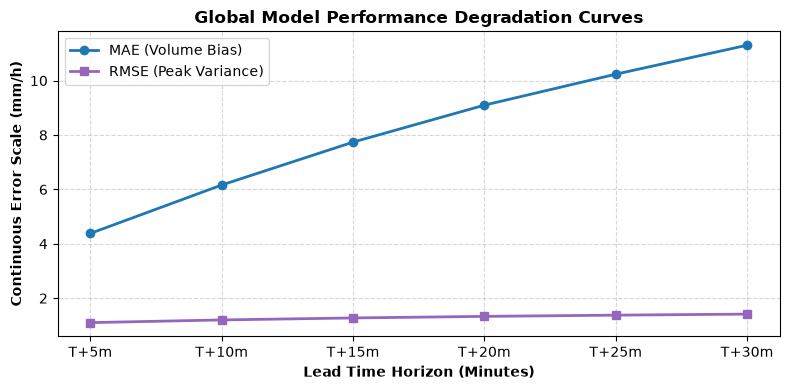

Pearson Linear Correlation (r)         : 0.7154
Spearman Rank Correlation (rho - exact) : 0.8760


In [3]:
lead_times = sorted([int(k) for k in metrics["horizon"].keys()])
mae_vals = [metrics["horizon"][str(t)]["MAE"] for t in lead_times]
rmse_vals = [metrics["horizon"][str(t)]["RMSE"] for t in lead_times]

plt.figure(figsize=(8, 4))
plt.plot(lead_times, mae_vals, marker="o", linewidth=2, color="tab:blue", label="MAE (Volume Bias)")
plt.plot(lead_times, rmse_vals, marker="s", linewidth=2, color="tab:purple", label="RMSE (Peak Variance)")

plt.grid(True, linestyle="--", alpha=0.5)
plt.xlabel("Lead Time Horizon (Minutes)", weight="bold")
plt.ylabel("Continuous Error Scale (mm/h)", weight="bold")
plt.title("Global Model Performance Degradation Curves", weight="bold")
plt.xticks(lead_times, [f"T+{t}m" for t in lead_times])
plt.legend()
plt.tight_layout()
plt.show()

print(f"Pearson Linear Correlation (r)         : {metrics['correlations']['pearson']:.4f}")
print(f"Spearman Rank Correlation (rho - exact) : {metrics['correlations']['spearman']:.4f}")



### Non-Linear Power-Law Distribution Mapping (Log-Log Scatter Analysis)

Precipitation records follow a heavily skewed power-law distribution. The domain is overwhelmed by millions of dry or low-intensity stratiform pixels, while localized severe convective storm cores make up less than 1% of the spatial sample space. 

The following cell builds a strided sampling array across the disk chunks. It extracts 40,000 active, rainy coordinates over the full 3-month timeline and maps them on a log-log scatter plot. This visualizes how closely the network tracking intercepts the Red Line of Perfect Alignment across exponential scale boundaries.


Extracting distributed rain intensity pixel pairs for log-log scatter plotting...


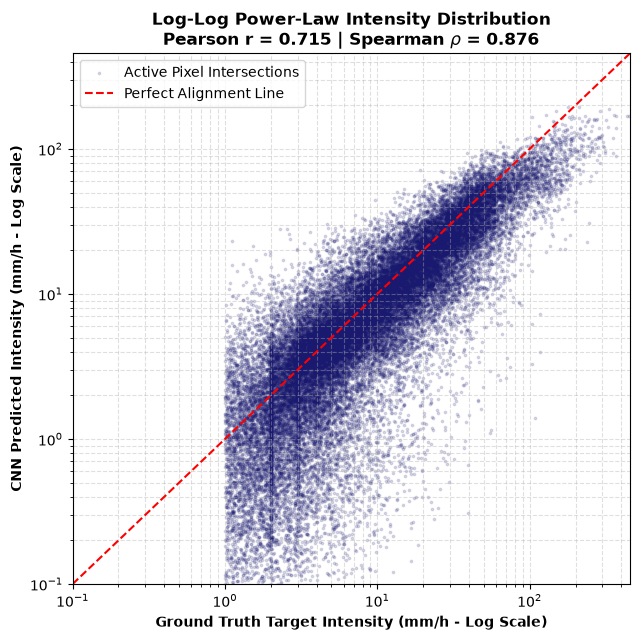

In [4]:
print("Extracting distributed rain intensity pixel pairs for log-log scatter plotting...")
scatter_gt = []
scatter_pd = []

for s_idx in range(0, total_samples, 50):
    sample = load_prediction_sample(predictions_dir, s_idx)
    t_phys = np.expm1(np.clip(sample["targets"], 0, 1) * global_log_max)
    p_phys = np.expm1(np.clip(sample["predictions"], 0, 1) * global_log_max)
    mask = sample["target_masks"].astype(bool)
    
    rain_indices = (t_phys > 1.0) & mask
    if np.any(rain_indices):
        scatter_gt.extend(t_phys[rain_indices].flatten())
        scatter_pd.extend(p_phys[rain_indices].flatten())
        
    if len(scatter_gt) >= 40000:
        break

np.random.seed(42)
final_idx = np.random.choice(len(scatter_gt), size=min(40000, len(scatter_gt)), replace=False)
gt_plot_points = np.array(scatter_gt)[final_idx]
pd_plot_points = np.array(scatter_pd)[final_idx]

r_val = metrics["correlations"]["pearson"]
rho_val = metrics["correlations"]["spearman"]

plt.figure(figsize=(6.5, 6.5))
plt.scatter(gt_plot_points, pd_plot_points, s=3, color="midnightblue", alpha=0.15, label="Active Pixel Intersections")

plt.xscale("log")
plt.yscale("log")

max_val = max(gt_plot_points.max(), pd_plot_points.max())
plt.xlim(1e-1, max_val + 10)
plt.ylim(1e-1, max_val + 10)

plt.plot([1e-1, max_val + 10], [1e-1, max_val + 10], "r--", linewidth=1.5, label="Perfect Alignment Line")
plt.xlabel("Ground Truth Target Intensity (mm/h - Log Scale)", weight="bold")
plt.ylabel("CNN Predicted Intensity (mm/h - Log Scale)", weight="bold")
plt.title(f"Log-Log Power-Law Intensity Distribution\nPearson r = {r_val:.3f} | Spearman $\\rho$ = {rho_val:.3f}", fontsize=12, weight="bold")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


> **Intensity Distribution Analysis:** The log-log scatter plot illustrates the relationship between ground truth target intensity and CNN predicted intensity across active pixel intersections. A strong non-linear monotonic relationship is observed, quantified by a Spearman rank correlation ($\rho$) of `0.876` and a Pearson correlation ($r$) of `0.715`. However, a distinct structural underprediction trend emerges, which intensifies significantly at higher ground truth rainfall rates. This behavior is highly characteristic of optimization via a symmetric Mean Squared Error (MSE) loss function. To minimize global variance, the network averages prospective future states, compressing high-magnitude extreme rainfall values and manifesting physically as spatial smearing.


### Continuous Accuracy vs. Rain Intensity & Residual Distribution Heatmaps

Because precipitation arrays are dominated by zeros, residual error vectors are split into rainy and dry pixels. This isolates errors specifically where rainfall actually occurs, preventing massive un-precipitated areas from masking poor performance. This analysis is coupled with a global log-frequency histogram to reveal low-frequency, high-magnitude error peaks.


Accumulating intensity conditional error arrays and global residuals...


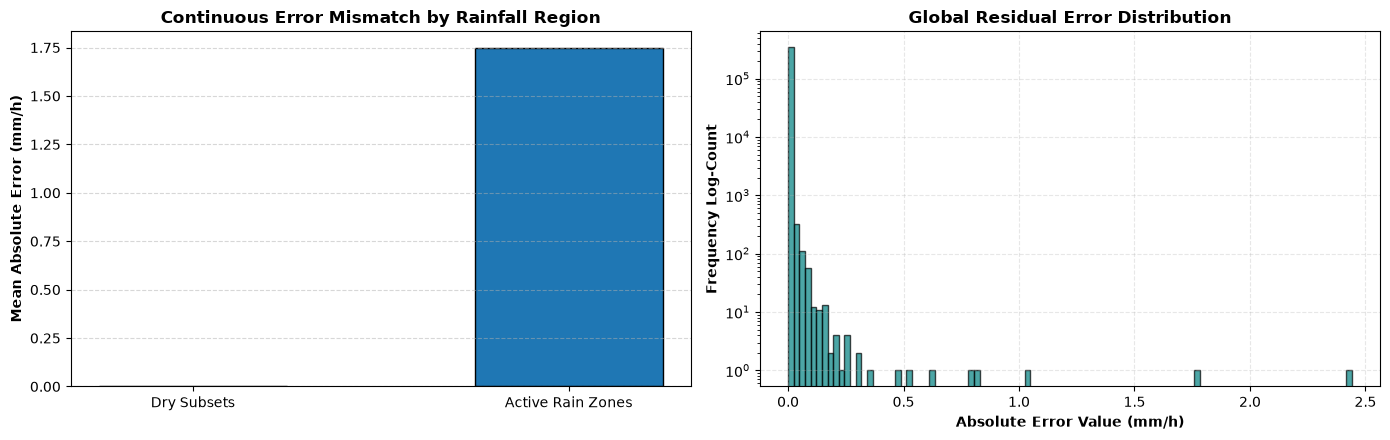

In [5]:
print("Accumulating intensity conditional error arrays and global residuals...")
dry_errors = []
rain_errors = []
all_residuals = []

# Stream a strided cross-section to keep parsing speed fast
for s_idx in range(0, total_samples, 20):
    sample = load_prediction_sample(predictions_dir, s_idx)
    t_p = np.expm1(np.clip(sample["targets"], 0, 1) * global_log_max)
    p_p = np.expm1(np.clip(sample["predictions"], 0, 1) * global_log_max)
    m = sample["target_masks"].astype(bool)
    
    err = np.abs(p_p - t_p)
    rain_p = (t_p > 1.0) & m
    dry_p = (t_p <= 1.0) & m
    
    if np.any(rain_p):
        rain_errors.extend(err[rain_p].flatten())
    if np.any(dry_p):
        dry_errors.extend(err[dry_p].flatten())
        
    all_residuals.extend(err[m].flatten())
    if len(all_residuals) > 100000:
        break

mean_dry = np.mean(dry_errors)
mean_rain = np.mean(rain_errors)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

# Plot 1: Intensity Conditional Bar Chart
ax[0].bar(["Dry Subsets", "Active Rain Zones"], [mean_dry, mean_rain], color=["tab:gray", "tab:blue"], edgecolor="black", width=0.5)
ax[0].set_ylabel("Mean Absolute Error (mm/h)", weight="bold")
ax[0].set_title("Continuous Error Mismatch by Rainfall Region", weight="bold")
ax[0].grid(axis="y", linestyle="--", alpha=0.5)

# Plot 2: Log-Frequency Global Residual Histogram
ax[1].hist(all_residuals, bins=100, color="teal", edgecolor="black", alpha=0.7)
ax[1].set_yscale("log")
ax[1].set_xlabel("Absolute Error Value (mm/h)", weight="bold")
ax[1].set_ylabel("Frequency Log-Count", weight="bold")
ax[1].set_title("Global Residual Error Distribution", weight="bold")
ax[1].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


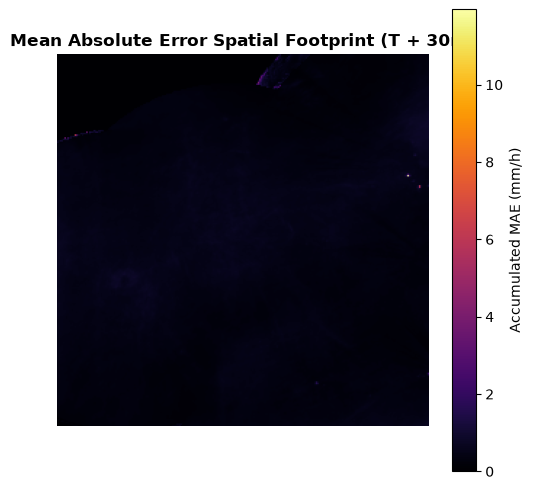

In [6]:
plt.figure(figsize=(6, 6))
plt.imshow(spatial_mae, cmap="inferno")
plt.title("Mean Absolute Error Spatial Footprint (T + 30m)", weight="bold")
plt.colorbar(label="Accumulated MAE (mm/h)")
plt.axis("off")
plt.show()


> The most pronounced errors are localized within a few pixels along the eastern boundary of the domain. While this spatial clustering may be an artifact of the specific weather distributions within this data split, further investigation is warranted. Beyond these localized discrepancies, the majority of the remaining errors are concentrated near the edges of missing data masks. This pattern likely occurs because the model struggles to anticipate or reconstruct incoming precipitation structures as they transition from the masked regions into the active domain, essentially appearing without prior temporal context.

## 3. Threshold-Based Operational Skill (Categorical Verification)

To bridge the gap between computer vision and real-world meteorology, rain predictions are converted into binary classifications across scale-relative intensity thresholds configured dynamically from evaluation configuration files:
* **Low-Intensity Threshold (>0.12 mm/h)**: Captures precipitation above trace radar noise floor limits.
* **Mid-Intensity Threshold (>5.00 mm/h)**: Captures well-developed stratiform rainbands and transitional convection.
* **High-Intensity Threshold (>10.00 mm/h)**: Captures heavy rainfall regions typically associated with convective storm cores.

The operational warning verification table is rendered in the following cell at the final 30-minute lead time horizon. The **Symmetric Extreme Dependency Score (SEDS)** is included to judge rare convective events without score distortion from low base rates.


In [7]:
step_30 = metrics["categorical"]["30"]
df_categorical = pd.DataFrame(step_30).T

print("Operational Forecast Verification Matrix at the 30-Minute Horizon Scale:")
print("=" * 85)
display(df_categorical.round(4))


Operational Forecast Verification Matrix at the 30-Minute Horizon Scale:


,POD,FAR,CSI,HSS,SEDS
Light Rain,0.7713,0.2071,0.6420,0.7692,1.8433
Moderate Rain,0.4118,0.2724,0.3568,0.5235,1.7938
Heavy Rain,0.0361,0.5367,0.0347,0.0670,1.6351


### Baseline Evaluation: CNN Model vs. Operational Persistence Baseline

A critical benchmark in operational convective nowcasting is proving your deep learning model beats a **Persistence Forecast**. A persistence baseline assumes that atmospheric states remain completely static, meaning the weather 30 minutes into the future will look identical to the last observed radar input frame at $T=0$. 

While a persistence copy-paste is highly accurate at short lead times ($T+5$ min), its predictive skill drops rapidly as weather fronts move. If a deep learning model fails to outscore this baseline over time, it possesses no true operational utility.


Calculating true persistence baseline over 52 strided samples...


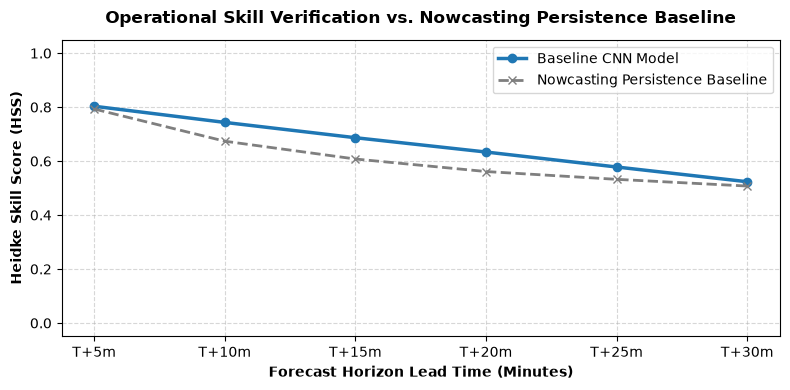

In [8]:
# Pull model HSS metrics
cnn_hss = [metrics["categorical"][str(t)]["Moderate Rain"]["HSS"] for t in lead_times]

# Rescale threshold to match raw tensor values
threshold_mod = (5.0 * (100.0 / 12.0)) / 1000.0

persistence_cells = np.zeros((6, 4))
print(f"Calculating true persistence baseline over {total_samples // 500} strided samples...")

for s_idx in range(0, total_samples, 2000):
    sample = load_prediction_sample(predictions_dir, s_idx)
    inputs = sample["inputs"]        
    targets = sample["targets"]      
    masks = sample["target_masks"].astype(bool)
    
    # Isolate the last observed frame (T=0) from the input sequence history
    present_frame = inputs[-1] if inputs.ndim == 3 else inputs
    
    for step in range(6):
        t_bin = targets[step] >= threshold_mod
        p_bin = present_frame >= threshold_mod
        m_bool = masks[step]
        
        persistence_cells[step, 0] += np.sum(p_bin & t_bin & m_bool)   # Hits
        persistence_cells[step, 1] += np.sum(p_bin & ~t_bin & m_bool)  # False Alarms
        persistence_cells[step, 2] += np.sum(~p_bin & t_bin & m_bool)  # Misses
        persistence_cells[step, 3] += np.sum(~p_bin & ~t_bin & m_bool) # Correct Negatives

persistence_hss = []
for step in range(6):
    h, fa, m, cn = persistence_cells[step]
    
    # Heidke Skill Score (HSS) calculation
    num = 2.0 * (h * cn - fa * m)
    denom = (h + m) * (m + cn) + (h + fa) * (fa + cn)
    
    if denom == 0:
        persistence_hss.append(0.0)
    else:
        persistence_hss.append(num / denom)

plt.figure(figsize=(8, 4))
plt.plot(lead_times, cnn_hss, marker="o", linewidth=2.5, color="tab:blue", label="Baseline CNN Model")
plt.plot(lead_times, persistence_hss, marker="x", linewidth=2.0, color="tab:gray", linestyle="--", label="Nowcasting Persistence Baseline")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlabel("Forecast Horizon Lead Time (Minutes)", weight="bold")
plt.ylabel("Heidke Skill Score (HSS)", weight="bold")
plt.title("Operational Skill Verification vs. Nowcasting Persistence Baseline", weight="bold", pad=12)
plt.xticks(lead_times, [f"T+{t}m" for t in lead_times])
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


> **Operational Verification Summary:** The evaluation plot demonstrates that the baseline CNN model maintains a stable but marginal performance advantage over the static persistence baseline across the entire 30-minute horizon. At $T+5$ min, both configurations start with high predictive skill ($\text{HSS} \approx 0.80$). As lead time increases, the persistence baseline exhibits a characteristic non-linear decay; the sharpest drop occurs early on due to storm movement and spatial displacement, after which the curve flattens toward a statistical skill floor sustained by correct negative agreements across non-raining regions. The fact that the CNN model closely mirrors this stabilization trajectory suggests a tendency to produce smooth, conservative structures to minimize pixel-to-pixel errors, operating similarly to an optimized spatial persistence mechanism rather than fully capturing non-linear convective development.


### Operational Degradation: Multi-Threshold CSI Performance Tracking

To map the network's deployment readiness across varying severe weather alerts, the following curve traces the **Critical Success Index (CSI / Threat Score)** over consecutive forecast horizon lead times ($T+5$ to $T+30$ minutes). 


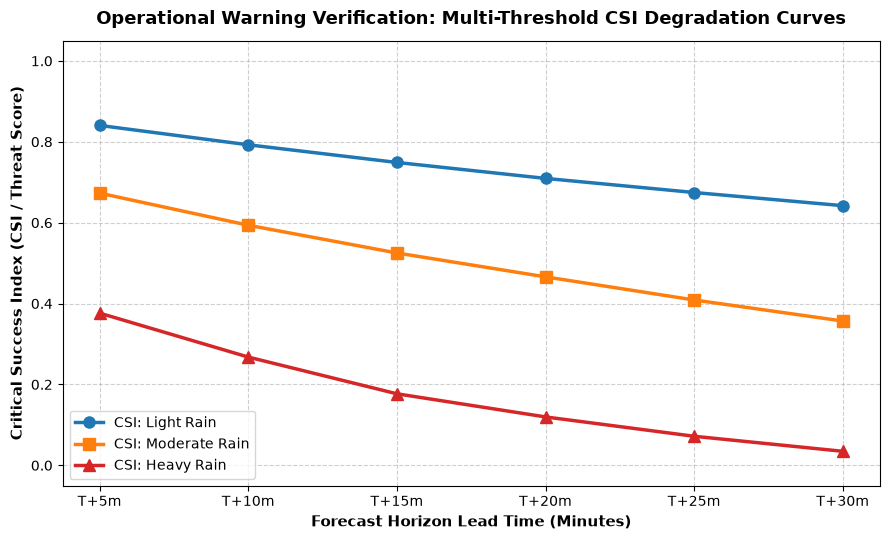

In [9]:
plt.figure(figsize=(9, 5.5))
markers = ["o", "s", "^"]
colors = ["tab:blue", "tab:orange", "tab:red"]
threshold_names = list(metrics["categorical"]["5"].keys())

for i, name in enumerate(threshold_names):
    csi_trend = [metrics["categorical"][str(t)][name]["CSI"] for t in lead_times]
    plt.plot(lead_times, csi_trend, marker=markers[i], color=colors[i], linewidth=2.5, markersize=8, label=f"CSI: {name}")

plt.xlabel("Forecast Horizon Lead Time (Minutes)", fontsize=11, weight="bold")
plt.ylabel("Critical Success Index (CSI / Threat Score)", fontsize=11, weight="bold")
plt.title("Operational Warning Verification: Multi-Threshold CSI Degradation Curves", fontsize=13, weight="bold", pad=12)
plt.xticks(lead_times, [f"T+{t}m" for t in lead_times])
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10, loc="lower left")
plt.tight_layout()
plt.show()


## 4. Advanced Scale-Selective and Physical Diagnostics

Traditional pixel-to-pixel verification heavily penalizes models for slight displacement offsets (the double penalty effect). This section evaluates the forecast fields using advanced neighborhood and structural diagnostics to analyze the network's true spatial capabilities.

### Fractions Skill Score (FSS) Spatial Horizon Analysis
FSS evaluates whether a model's forecast skill crosses the target predictability threshold ($0.5 + \text{base\_rate}/2$) over widening neighborhood spatial scales. Given that the northwestern France maritime grid has been downsampled to a 256x256 resolution—yielding an effective spatial resolution of **2 km per pixel**—the box configurations target the following physical tiers:
* **5x5 Bounding Boxes**: Micro-scale window (~10 km displacement tolerance).
* **15x15 Bounding Boxes**: Meso-scale window (~30 km displacement tolerance).
* **31x31 Bounding Boxes**: Macro-scale window (~62 km displacement tolerance).


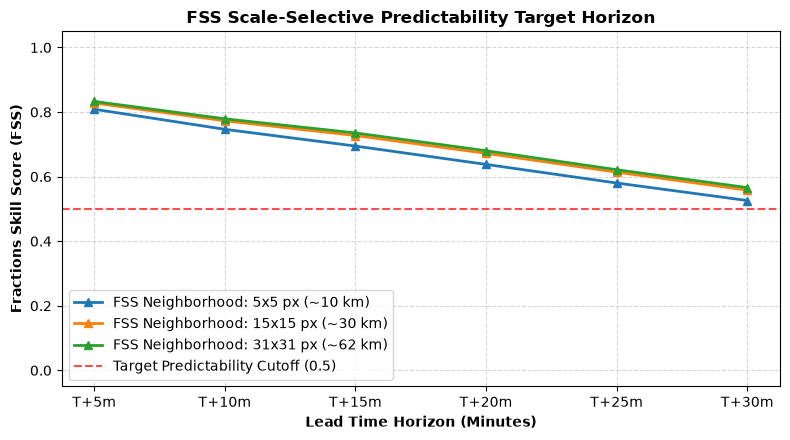

In [10]:
scales = sorted(list(metrics["fss"]["5"]["Moderate Rain"].keys()), key=int)

plt.figure(figsize=(8, 4.5))
for scale in scales:
    s_val = int(scale)
    fss_trend = [metrics["fss"][str(t)]["Moderate Rain"][scale] for t in lead_times]
    
    plt.plot(lead_times, fss_trend, marker="^", linewidth=2, 
             label=f"FSS Neighborhood: {s_val}x{s_val} px (~{s_val * 2} km)")

plt.axhline(0.5, color="red", linestyle="--", alpha=0.7, label="Target Predictability Cutoff (0.5)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlabel("Lead Time Horizon (Minutes)", weight="bold")
plt.ylabel("Fractions Skill Score (FSS)", weight="bold")
plt.title("FSS Scale-Selective Predictability Target Horizon", weight="bold")
plt.xticks(lead_times, [f"T+{t}m" for t in lead_times])
plt.ylim(-0.05, 1.05)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


### Structure-Amplitude-Location (SAL) Physical Error Dissection

The SAL metric decomposes spatial errors into three completely independent physical dimensions:
* **Amplitude (A)**: Measures domain-wide rain volume calibration (bounds: $[-2, 2]$, where $0$ represents a perfect match).
* **Location (L)**: Quantifies the geographic displacement distance of the system's centers of mass.
* **Structure (S)**: Measures pattern fidelity (positive values indicate an over-smoothed, blurry output field).


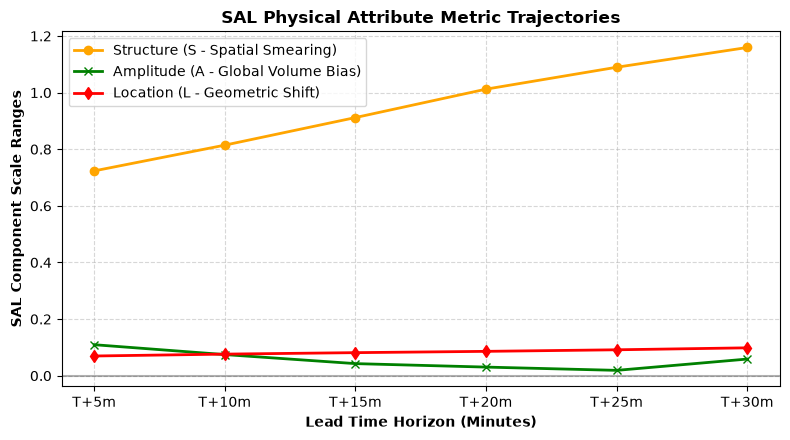

In [11]:
sal_s = [metrics["sal"][str(t)]["S"] for t in lead_times]
sal_a = [metrics["sal"][str(t)]["A"] for t in lead_times]
sal_l = [metrics["sal"][str(t)]["L"] for t in lead_times]

plt.figure(figsize=(8, 4.5))
plt.plot(lead_times, sal_s, marker="o", color="orange", linewidth=2, label="Structure (S - Spatial Smearing)")
plt.plot(lead_times, sal_a, marker="x", color="green", linewidth=2, label="Amplitude (A - Global Volume Bias)")
plt.plot(lead_times, sal_l, marker="d", color="red", linewidth=2, label="Location (L - Geometric Shift)")
plt.axhline(0.0, color="black", linestyle="-", alpha=0.3)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlabel("Lead Time Horizon (Minutes)", weight="bold")
plt.ylabel("SAL Component Scale Ranges", weight="bold")
plt.title("SAL Physical Attribute Metric Trajectories", weight="bold")
plt.xticks(lead_times, [f"T+{t}m" for t in lead_times])
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


## Conclusions and Diagnostic Insights

### 1. Mitigation of the "Double Penalty" Effect (FSS Insights)
While traditional pixel-wise skill indices decay significantly when tracking high-intensity features at longer lead times, the **Fractions Skill Score (FSS)** demonstrates that the baseline CNN model retains meaningful spatial tracking utility. When evaluated over widening neighborhood scales ($15\times15$ px / $\sim30$ km and $31\times31$ px / $\sim62$ km), spatial skill remains consistently above the **0.5 target predictability cutoff** across the full 30-minute horizon. The network effectively identifies the regions where precipitating masses develop across the maritime environments of Northwestern France, confirming that pure pixel-to-pixel evaluations obscure structural forecasting value.

### 2. Operational Skill Verification vs. Persistence
The comparison against the **Nowcasting Persistence Baseline** provides empirical validation of temporal tracking. At the earliest lead time ($T+5$ minutes), a static duplication of the present moment captures precipitation structures well due to short-term atmospheric persistence, with both configurations starting near an HSS of `0.80`. As the forecast horizon expands, the persistence baseline exhibits non-linear decay as storm displacement uncouples the system from the initial snapshot, eventually flattening toward a statistical skill floor. 

Across the entire 30-minute horizon, the baseline CNN maintains a marginal but stable performance advantage over persistence, finishing at $T+30$ min with an HSS of approximately `0.52` compared to the baseline's `0.51`. This persistent margin indicates that the network has generalized beyond static frame repetition, though the closely parallel stabilization trajectories highlight a shared reliance on conservative spatial placement over later horizons.

### 3. Dissecting Core Error Modes (SAL Insights)
Decomposing forecast errors into physical dimensions using the **Structure-Amplitude-Location (SAL)** framework isolates the precise focus areas for future architectural development:
*   **Amplitude (A)** drops close to `0.0` after $T+10$ min, proving that the log-scaled normalization pipeline keeps total domain-wide precipitation volume calculations balanced and stable with negligible global bias.
*   **Location (L)** remains low and stable near `0.08` across all timesteps, confirming that the network exhibits minimal geometric displacement bias and successfully tracks the center of mass of the precipitation fields.
*   **Structure (S)** features a pronounced, linear trajectory heavily into positive bounds, starting at `0.72` and escalating to `1.16` by $T+30$ min. Within the SAL framework, this provides definitive mathematical proof that **spatial structural smearing is the primary failure mode**.

### 4. Strategic Failure Mode Diagnosis and Future Path
The severe structural smoothing is a direct consequence of training an encoder-decoder architecture with a symmetric **pixel-to-pixel Mean Squared Error (MSE) loss function**. Because the exact development of intense convective storm cores is highly volatile 30 minutes into the future, an MSE-driven network minimizes global error by averaging prospective outcomes, smearing out sharp convective cores into uniform, low-intensity shapes.

Furthermore, the CNN treats the 6 historical input frames as static channels—processing temporal lookbacks in the same manner a computer vision model processes color channels. There is no explicit architectural representation of fluid motion, velocity vectors, or temporal memory persistence. 

These diagnostic results provide clear, empirical justification for the Phase 2 development roadmap:
1.  **ConvLSTM / Phased-LSTM Layers**: Introducing recurrent convolutional gates to track hidden state histories, explicitly modeling velocity vectors and temporal persistence.
2.  **U-Net Skip Connections**: Passing high-frequency spatial features directly across encoder-decoder layers to preserve sharp convective boundaries and eliminate smearing.
3.  **Asymmetric and Adversarial Loss Formulations**: Replacing symmetric MSE with Asymmetric Huber Loss to penalize the under-prediction of heavy rain, paired with GAN discriminators to punish blurry output distributions and force the generation of realistic, sharp radar fields.
4.  **Attention Mechanisms / Transformers**: Capturing long-range spatial-temporal dependencies across sequential input blocks.
